In [23]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor

## Research Question :

 To what extent can structure__coherence be predicted from essay metadata (course, text_type) and surface-level textual features, without using the other rubric scores?

In [29]:
# HELPER FUNCTIONS 
def split_sentences(text):
    if pd.isna(text):
        return []
    text = str(text).strip()
    if not text:
        return []
    sents = re.split(r"[.!?]+", text)
    return [s.strip() for s in sents if s.strip()]

def split_words(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    return re.findall(r"\b\w+\b", text)

def word_count(text):
    return len(split_words(text))

def char_count(text):
    if pd.isna(text):
        return 0
    return len(str(text))

def sentence_count(text):
    return len(split_sentences(text))

def avg_sentence_length(text):
    sents = split_sentences(text)
    if len(sents) == 0:
        return 0.0
    lengths = [len(split_words(s)) for s in sents]
    return float(np.mean(lengths)) if len(lengths) > 0 else 0.0

def avg_word_length(text):
    words = split_words(text)
    if len(words) == 0:
        return 0.0
    return float(np.mean([len(w) for w in words]))

def lexical_diversity(text):
    words = split_words(text)
    if len(words) == 0:
        return 0.0
    return len(set(words)) / len(words)

def comma_count(text):
    if pd.isna(text):
        return 0
    return str(text).count(",")

def semicolon_count(text):
    if pd.isna(text):
        return 0
    return str(text).count(";")

def colon_count(text):
    if pd.isna(text):
        return 0
    return str(text).count(":")

def exclamation_count(text):
    if pd.isna(text):
        return 0
    return str(text).count("!")

def question_count(text):
    if pd.isna(text):
        return 0
    return str(text).count("?")

def long_word_ratio(text, min_len=7):
    words = split_words(text)
    if len(words) == 0:
        return 0.0
    return sum(len(w) >= min_len for w in words) / len(words)

In [3]:
# Directory
print("Python working directory:", os.getcwd())

data_dir = './data'
assert os.path.isdir(data_dir), f"File not found: {data_dir}" # check files exist

Python working directory: /Users/louistschanz/Documents/EPFL/MA4/MLBD_2026


In [4]:

essay_results = pd.read_csv('{}/essay_results.csv'.format(data_dir))

In [30]:
# dataframe de travail
df_clean = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_clean = df_clean.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

# features engeneering
df_clean["word_count"] = df_clean["text"].apply(word_count)
df_clean["char_count"] = df_clean["text"].apply(char_count)
df_clean["sentence_count"] = df_clean["text"].apply(sentence_count)
df_clean["avg_sentence_length"] = df_clean["text"].apply(avg_sentence_length)
df_clean["avg_word_length"] = df_clean["text"].apply(avg_word_length)
df_clean["lexical_diversity"] = df_clean["text"].apply(lexical_diversity)
df_clean["comma_count"] = df_clean["text"].apply(comma_count)
df_clean["semicolon_count"] = df_clean["text"].apply(semicolon_count)
df_clean["colon_count"] = df_clean["text"].apply(colon_count)
df_clean["exclamation_count"] = df_clean["text"].apply(exclamation_count)
df_clean["question_count"] = df_clean["text"].apply(question_count)
df_clean["long_word_ratio"] = df_clean["text"].apply(long_word_ratio)


# ===== 4) X / y =====
feature_cols = [
    "course",
    "text_type",
    "word_count",
    "char_count",
    "sentence_count",
    "avg_sentence_length",
    "avg_word_length",
    "lexical_diversity",
    "comma_count",
    "semicolon_count",
    "colon_count",
    "exclamation_count",
    "question_count",
    "long_word_ratio",
]

X = df_clean[feature_cols].copy()
y = df_clean["structure__coherence"].copy()

print(df_clean.shape)
print(X.head())
print(y.head())

(10065, 16)
   course   text_type  word_count  char_count  sentence_count  \
0    5447  erzaehlung         491        3048              41   
1    5447  erzaehlung         579        3542              60   
2    5447  erzaehlung         310        1897              25   
3    5447  erzaehlung         582        3686              60   
4    5447  erzaehlung          96         569               4   

   avg_sentence_length  avg_word_length  lexical_diversity  comma_count  \
0             11.97561         4.997963           0.584521           24   
1              9.65000         4.744387           0.426598           37   
2             12.40000         4.948387           0.561290           18   
3              9.70000         4.970790           0.426117           37   
4             24.00000         4.802083           0.750000            9   

   semicolon_count  colon_count  exclamation_count  question_count  \
0                0            1                  3               3   
1     

In [31]:
cat_cols = ["course", "text_type"]
num_cols = [c for c in feature_cols if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)

mlp_model_clean = Pipeline([
    ("prep", preprocessor),
    ("reg", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

mlp_model_clean.fit(X_train, y_train)
y_pred = mlp_model_clean.predict(X_test)

In [32]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("n_iter_ =", mlp_model_clean.named_steps["reg"].n_iter_)
print("final_loss =", mlp_model_clean.named_steps["reg"].loss_)

MAE : 0.9843959924265486
RMSE: 1.2713752802693878
R2  : 0.3279084200774921
n_iter_ = 60
final_loss = 0.7887518751372673


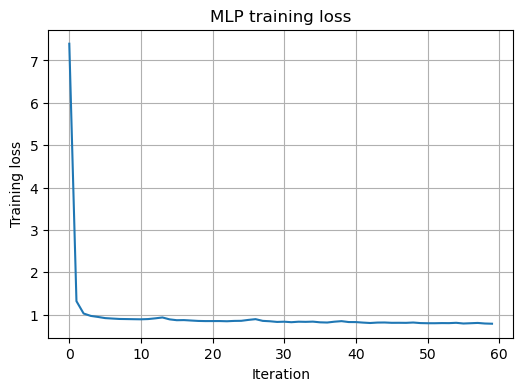

In [33]:

plt.figure(figsize=(6,4))
plt.plot(mlp_model_clean.named_steps["reg"].loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("MLP training loss")
plt.grid(True)
plt.show()

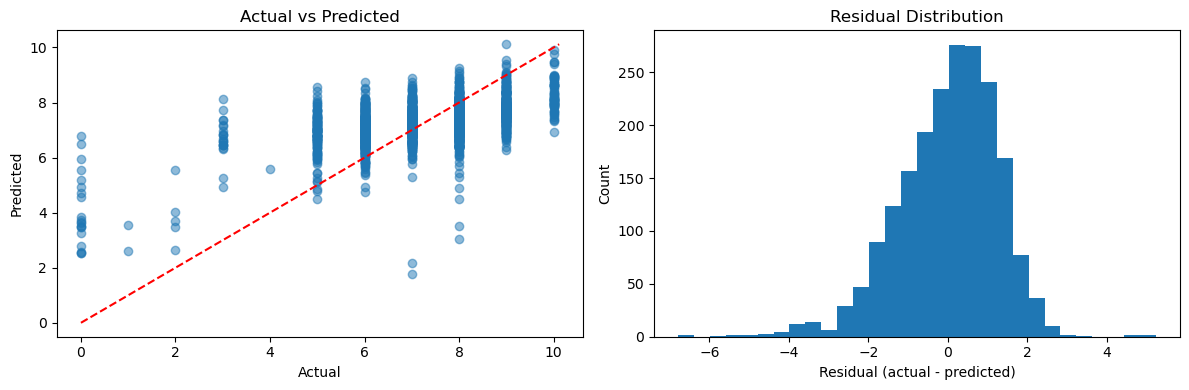

In [34]:
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax[0].plot(lims, lims, "r--")
ax[0].set_title("Actual vs Predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

ax[1].hist(residuals, bins=30)
ax[1].set_title("Residual Distribution")
ax[1].set_xlabel("Residual (actual - predicted)")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [35]:
pred_df = X_test.copy()
pred_df["y_true"] = y_test.values
pred_df["y_pred"] = y_pred
pred_df["abs_err"] = np.abs(pred_df["y_true"] - pred_df["y_pred"])

print("Top errors by course:")
display(pred_df.groupby("course")["abs_err"].mean().sort_values(ascending=False).head(10))

print("Top errors by text_type:")
display(pred_df.groupby("text_type")["abs_err"].mean().sort_values(ascending=False).head(10))

Top errors by course:


course
5447    0.990491
3301    0.974700
Name: abs_err, dtype: float64

Top errors by text_type:


text_type
bericht         1.030466
erzaehlung      1.008512
beschreibung    0.916116
eroerterung     0.868679
Name: abs_err, dtype: float64